In [1]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


Step 2: Import Libraries

In [4]:
import os
import zipfile
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mediapipe as mp

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


Step 3: Check Upload Dataset

In [5]:
os.listdir("/content")

['.config', 'HandInfo.csv', 'Hands.zip', 'sample_data']

Step 4: Load CSV

In [6]:
df = pd.read_csv("/content/HandInfo.csv")

Step 5: Display First Five Rows

In [7]:
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


Step 6: Dataset Shape

In [8]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 11076
Columns : 9


Step 7: Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


Step 8: Missing Values

In [10]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


Step 9: Duplicate Rows

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


Step 10: Statistical Summary

In [12]:
df.describe(include="all")

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
count,1.107600e+04,11076.000000,11076,11076,11076.000000,11076.000000,11076,11076,11076.000000
unique,NaN,NaN,2,4,NaN,NaN,4,11076,NaN
top,NaN,NaN,female,medium,NaN,NaN,dorsal right,Hand_0011744.jpg,NaN
freq,NaN,NaN,7109,6495,NaN,NaN,2892,1,NaN
mean,2.031043e+05,22.494583,NaN,NaN,0.289906,0.096334,NaN,NaN,0.014807
std,1.086731e+06,6.918974,NaN,NaN,0.453739,0.295063,NaN,NaN,0.120784
min,0.000000e+00,18.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
25%,5.760000e+02,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
50%,1.050000e+03,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
75%,1.539250e+03,22.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000


Step 11: Column Names

In [13]:
df.columns.tolist()

['id',
 'age',
 'gender',
 'skinColor',
 'accessories',
 'nailPolish',
 'aspectOfHand',
 'imageName',
 'irregularities']

Step 12: Check Age Distribution

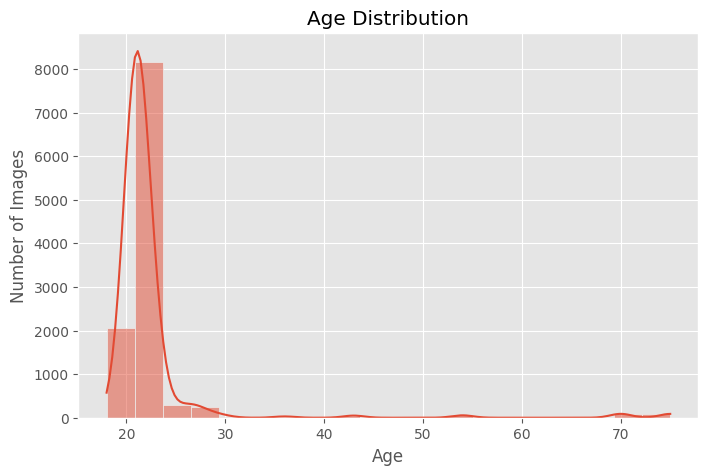

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.show()

Step 13: Gender Distribution

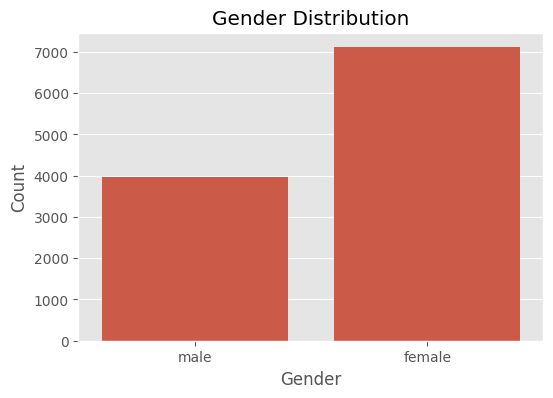

gender
female    7109
male      3967
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

print(df['gender'].value_counts())

Step 14: Skin Color Distribution

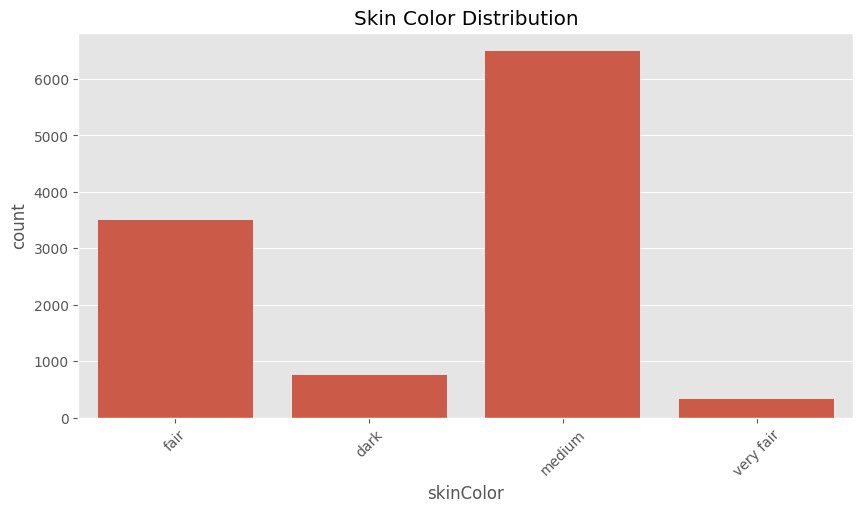

skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x='skinColor', data=df)

plt.title("Skin Color Distribution")
plt.xticks(rotation=45)

plt.show()

print(df['skinColor'].value_counts())

Step 15: Accessories Distribution

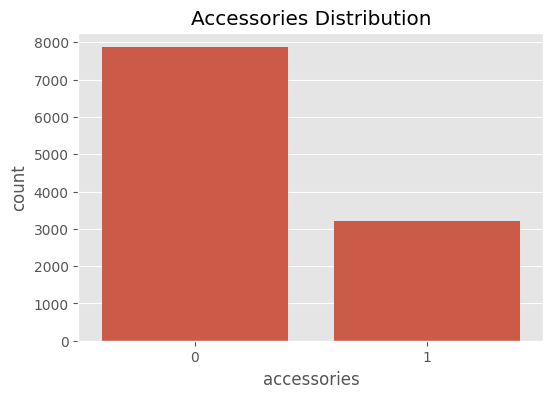

accessories
0    7865
1    3211
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='accessories', data=df)

plt.title("Accessories Distribution")

plt.show()

print(df['accessories'].value_counts())

Step 16: Nail Polish Distribution

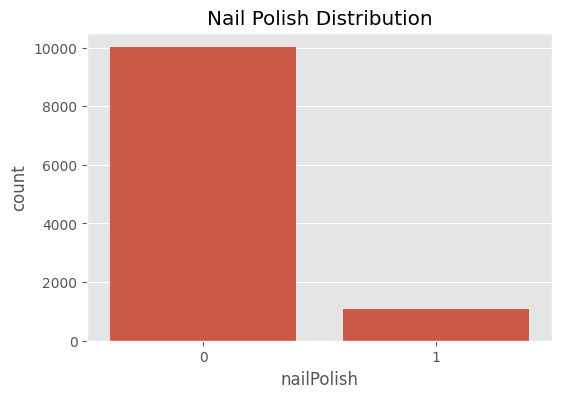

nailPolish
0    10009
1     1067
Name: count, dtype: int64


In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='nailPolish', data=df)

plt.title("Nail Polish Distribution")

plt.show()

print(df['nailPolish'].value_counts())

Step 17: Palm vs Dorsal Distribution

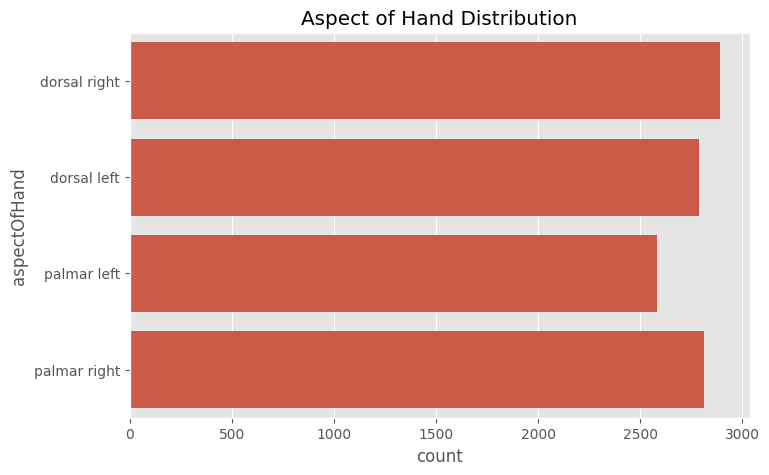

aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(8,5))

sns.countplot(y='aspectOfHand', data=df)

plt.title("Aspect of Hand Distribution")

plt.show()

print(df['aspectOfHand'].value_counts())

Step 18: Irregularities

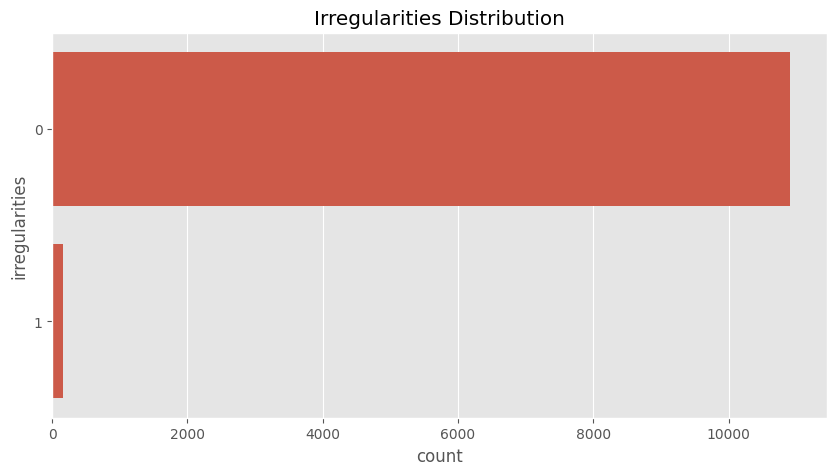

irregularities
0    10912
1      164
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(10,5))

sns.countplot(y='irregularities', data=df)

plt.title("Irregularities Distribution")

plt.show()

print(df['irregularities'].value_counts())

Step 19: Correlation (Numeric Features)

In [21]:
df.corr(numeric_only=True)

,id,age,accessories,nailPolish,irregularities
id,1.000000,0.126562,-0.030662,-0.060712,-0.006976
age,0.126562,1.000000,-0.098741,-0.062350,0.099821
accessories,-0.030662,-0.098741,1.000000,0.266177,-0.078332
nailPolish,-0.060712,-0.062350,0.266177,1.000000,-0.040027
irregularities,-0.006976,0.099821,-0.078332,-0.040027,1.000000


Step 20: Age by Gender

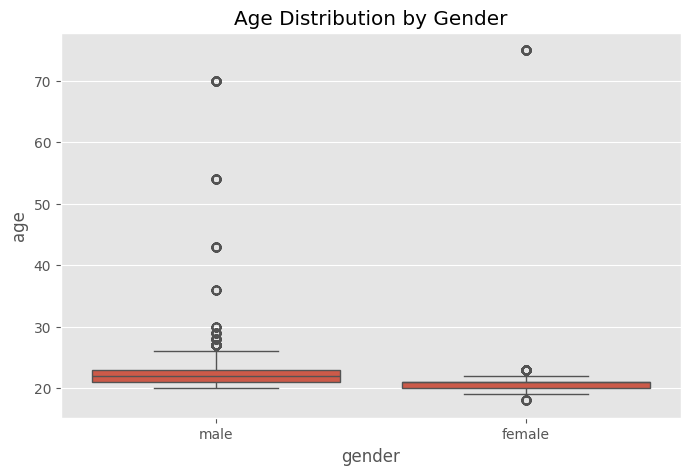

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x='gender', y='age', data=df)

plt.title("Age Distribution by Gender")

plt.show()

Step 21: Gender vs Skin Color

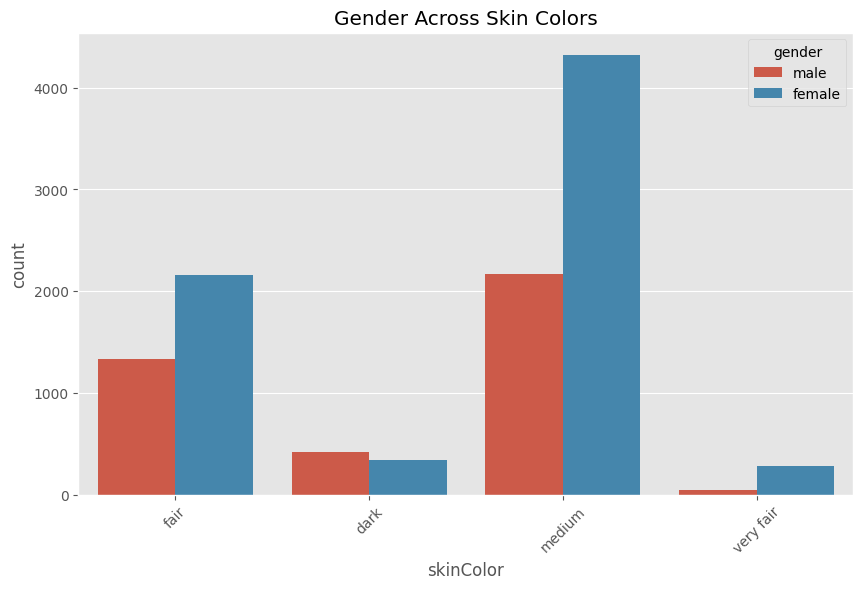

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(x='skinColor', hue='gender', data=df)

plt.xticks(rotation=45)

plt.title("Gender Across Skin Colors")

plt.show()

Step 22: Nail Polish vs Gender

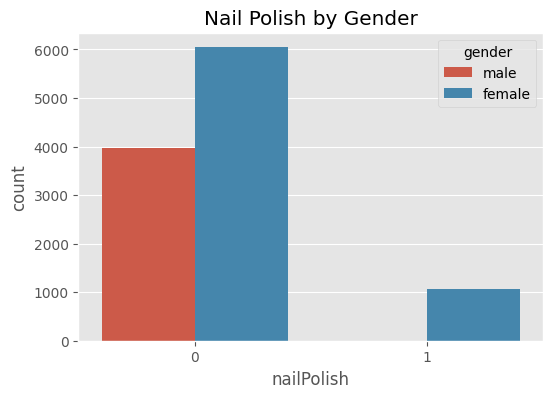

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='nailPolish', hue='gender', data=df)

plt.title("Nail Polish by Gender")

plt.show()

Step 23: Accessories vs Gender

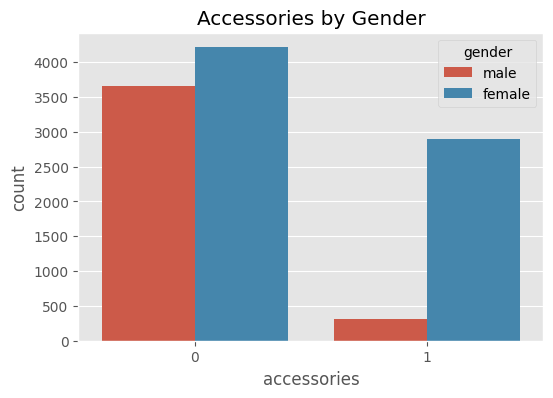

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='accessories', hue='gender', data=df)

plt.title("Accessories by Gender")

plt.show()

Step 24: Palm/Dorsal by Gender

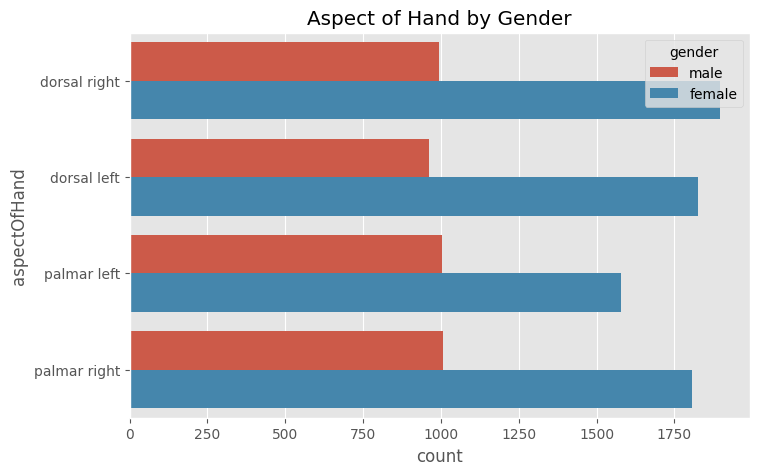

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(y='aspectOfHand', hue='gender', data=df)

plt.title("Aspect of Hand by Gender")

plt.show()

Step 25: Extract the Images

In [36]:
!pip install -q kaggle

In [37]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_dd900fec06fe1e63c14ed6cfa2ef8776"

In [38]:
!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
100% 634M/634M [00:04<00:00, 135MB/s]



In [40]:
!unzip -q /content/hands-and-palm-images-dataset.zip -d /content/palm_dataset

In [41]:
import os

os.listdir("/content/palm_dataset")

['HandInfo.csv', 'Hands']

Set the Image Folder

In [46]:
folder = "/content/palm_dataset/Hands/Hands"

files = os.listdir(folder)

print("Total Images:", len(files))

Total Images: 11076


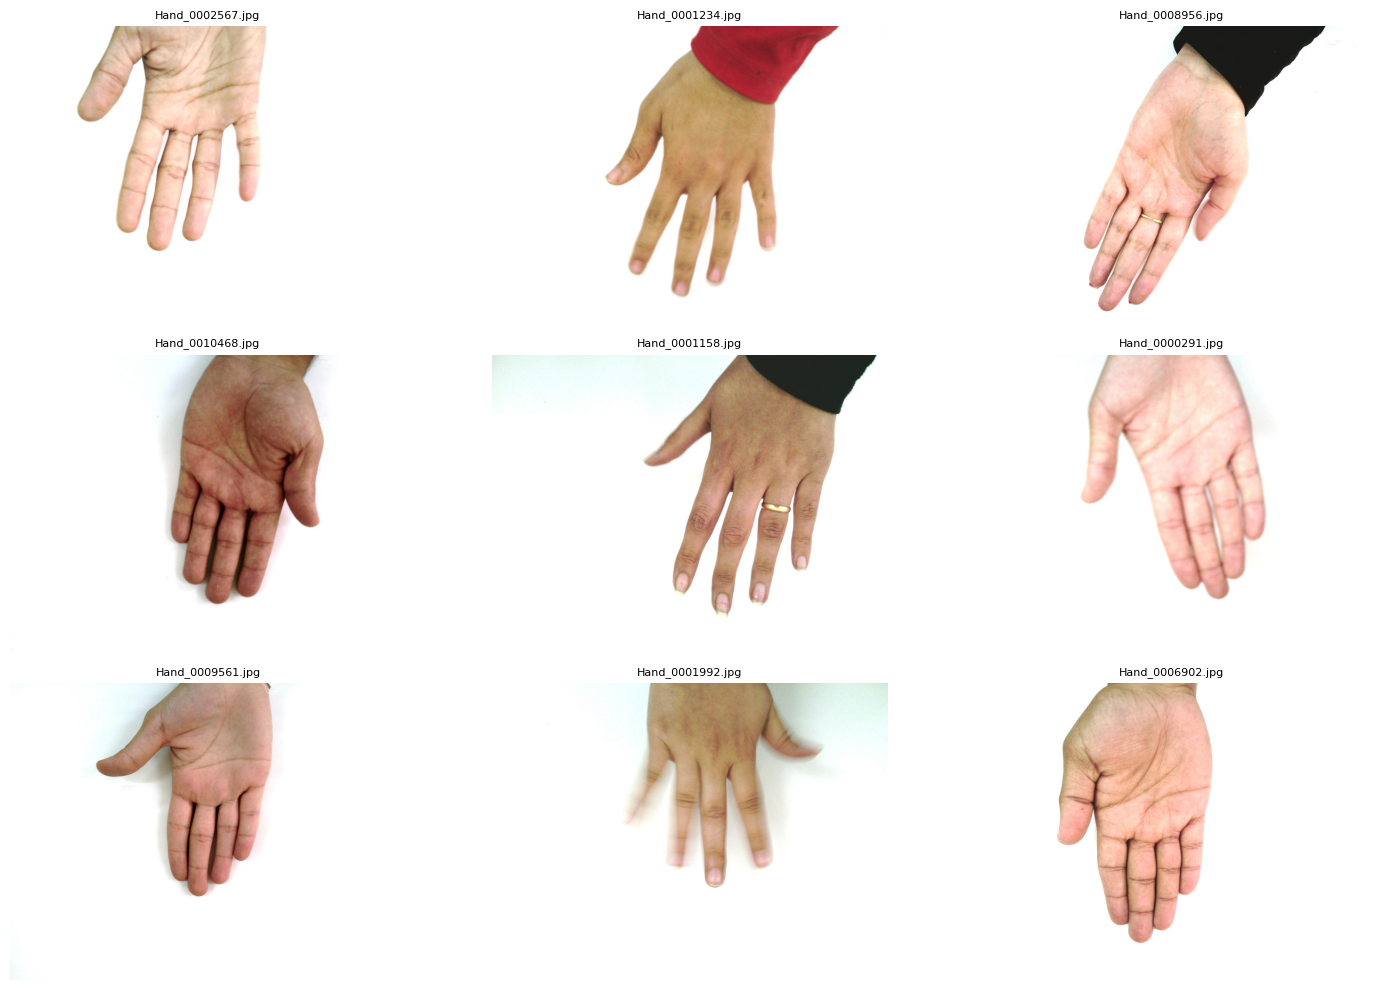

In [47]:
import matplotlib.pyplot as plt
import cv2
import os

plt.figure(figsize=(15,10))

for i, file in enumerate(files[:9]):

    img = cv2.imread(os.path.join(folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(file, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

Image Dimensions

In [48]:
widths = []
heights = []

for file in files:

    img = cv2.imread(os.path.join(folder, file))

    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

Average Width : 1600.0
Average Height: 1200.0
Minimum Width : 1600
Maximum Width : 1600
Minimum Height: 1200
Maximum Height: 1200


Image Size Distribution

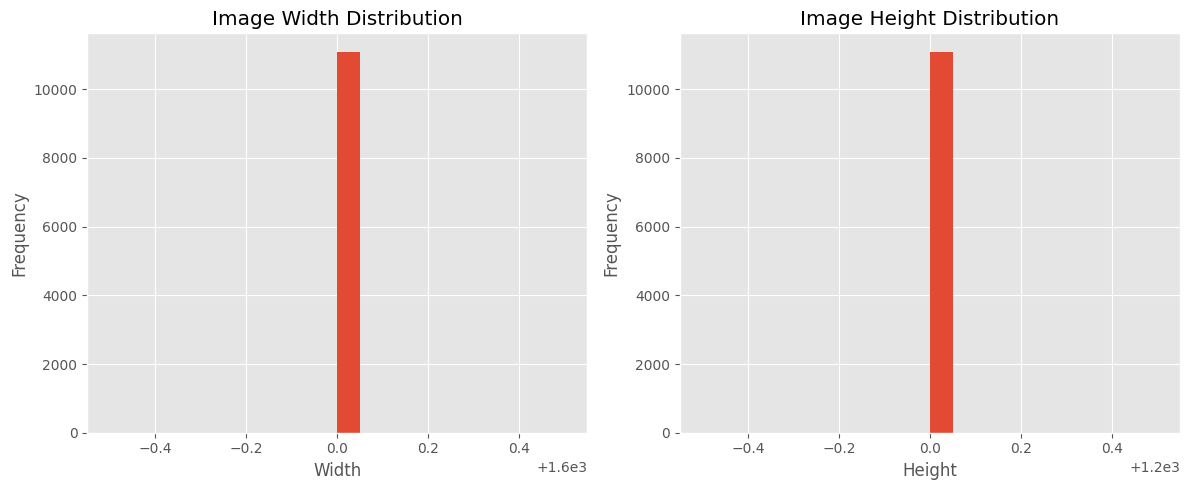

In [49]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

RGB Histogram

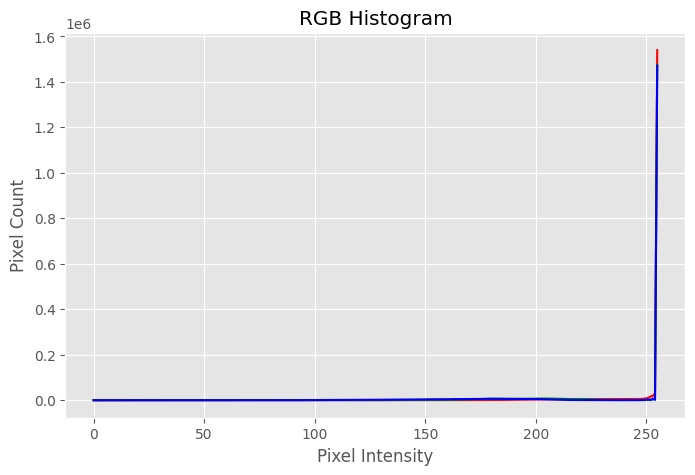

In [50]:
sample = cv2.imread(os.path.join(folder, files[0]))
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))

for i, color in enumerate(('r','g','b')):
    hist = cv2.calcHist([sample], [i], None, [256], [0,256])
    plt.plot(hist, color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixel Count")

plt.show()

Brightness Distribution

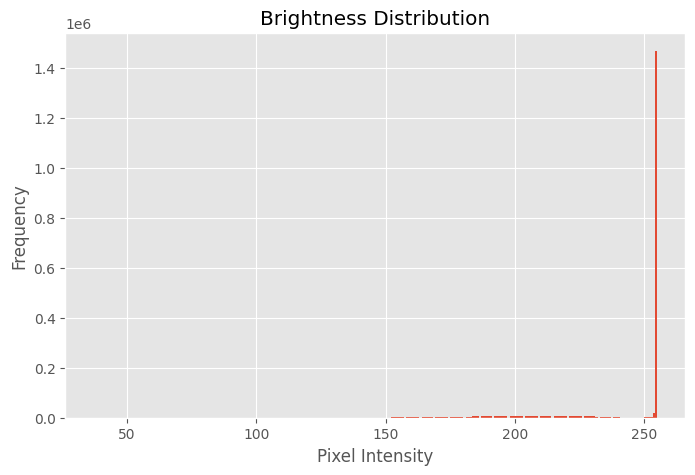

In [51]:
gray = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,5))

plt.hist(gray.ravel(), bins=256)

plt.title("Brightness Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()